In [1]:
%pip install -q tensorflow matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print("TensorFlow:",tf.__version__)
print("GPU available:,",tf.config.list_physical_devices('GPU'))


SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
GPU available:, []


In [3]:
DATA_ROOT = "PlantVillage-Dataset"
# if not os.path.exists(DATA_ROOT):
#     !git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git

DATA_DIR = os.path.join(DATA_ROOT , "raw","color")
print("Data dir:", DATA_DIR)
print("Number of classes:",len(os.listdir(DATA_DIR)))


Data dir: PlantVillage-Dataset\raw\color
Number of classes: 38


In [4]:
class_names = os.listdir(DATA_DIR)
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

{'Apple___Apple_scab': 630, 'Apple___Black_rot': 621, 'Apple___Cedar_apple_rust': 275, 'Apple___healthy': 1645, 'Blueberry___healthy': 1502, 'Cherry_(including_sour)___Powdery_mildew': 1052, 'Cherry_(including_sour)___healthy': 854, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 513, 'Corn_(maize)___Common_rust_': 1192, 'Corn_(maize)___Northern_Leaf_Blight': 985, 'Corn_(maize)___healthy': 1162, 'Grape___Black_rot': 1180, 'Grape___Esca_(Black_Measles)': 1383, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1076, 'Grape___healthy': 423, 'Orange___Haunglongbing_(Citrus_greening)': 5507, 'Peach___Bacterial_spot': 2297, 'Peach___healthy': 360, 'Pepper,_bell___Bacterial_spot': 997, 'Pepper,_bell___healthy': 1478, 'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000, 'Potato___healthy': 152, 'Raspberry___healthy': 371, 'Soybean___healthy': 5090, 'Squash___Powdery_mildew': 1835, 'Strawberry___Leaf_scorch': 1109, 'Strawberry___healthy': 456, 'Tomato___Bacterial_spot': 2127, 'Tomato_

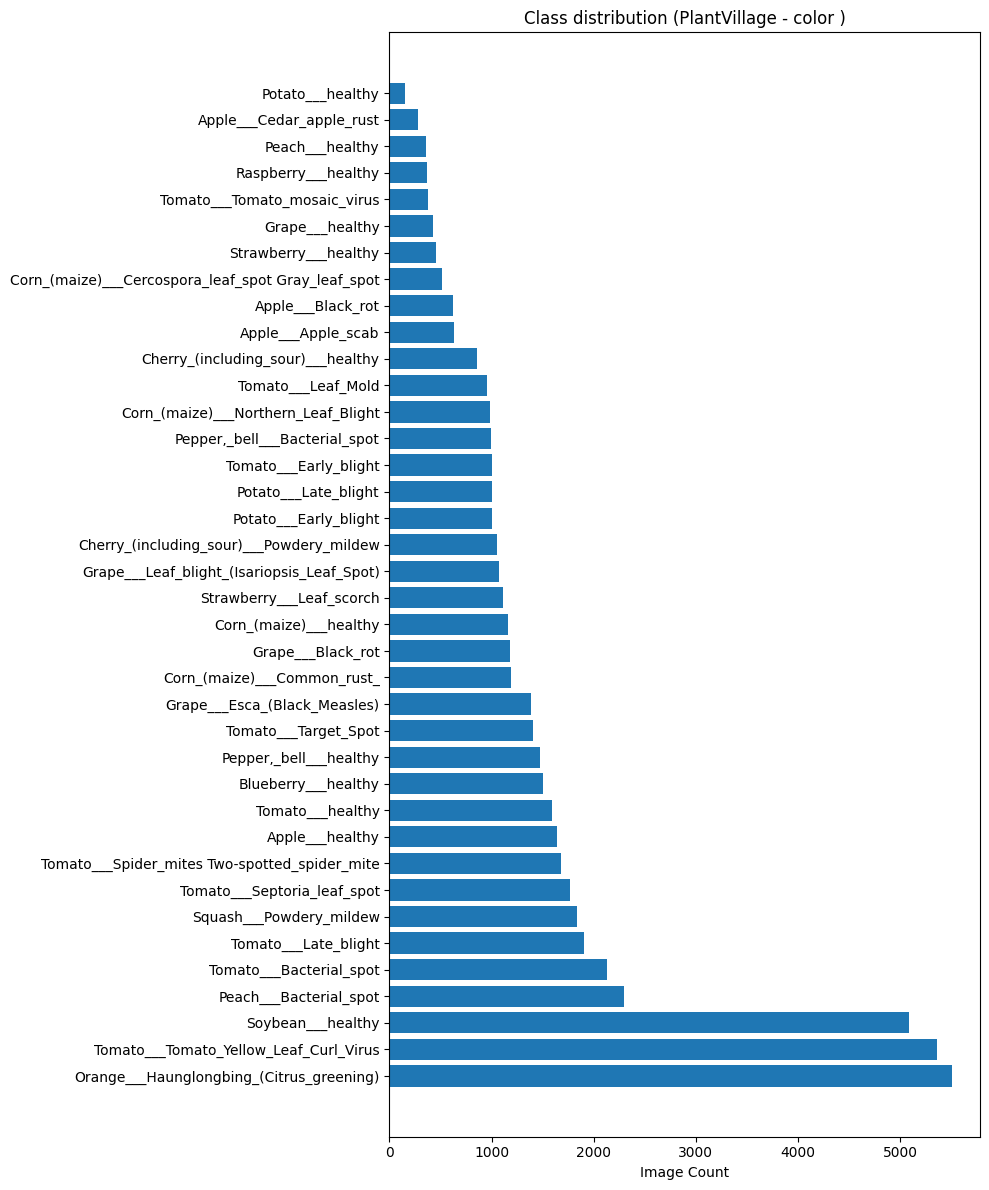

Min class size:152,Max class size :5507


In [5]:
class_names = sorted(os.listdir(DATA_DIR))
# count classes inside images
class_counts = {
    c : len(os.listdir(os.path.join(DATA_DIR , c)))
    for c in class_names
}
print(class_counts)
# sort counts of images in descending order 
sorted_counts = sorted(
    class_counts.items(),
    key=lambda x : x[1],
    reverse=True
)
print(sorted_counts)

# Create Graph
plt.figure(figsize=(10,12))
plt.barh(
    [c[0] for c in sorted_counts],
    [c[1] for c in sorted_counts]
    )
plt.xlabel("Image Count")
plt.title("Class distribution (PlantVillage - color )")
plt.tight_layout()
plt.show()

print(f"Min class size:{min(class_counts.values())},Max class size :{max(class_counts.values())}")



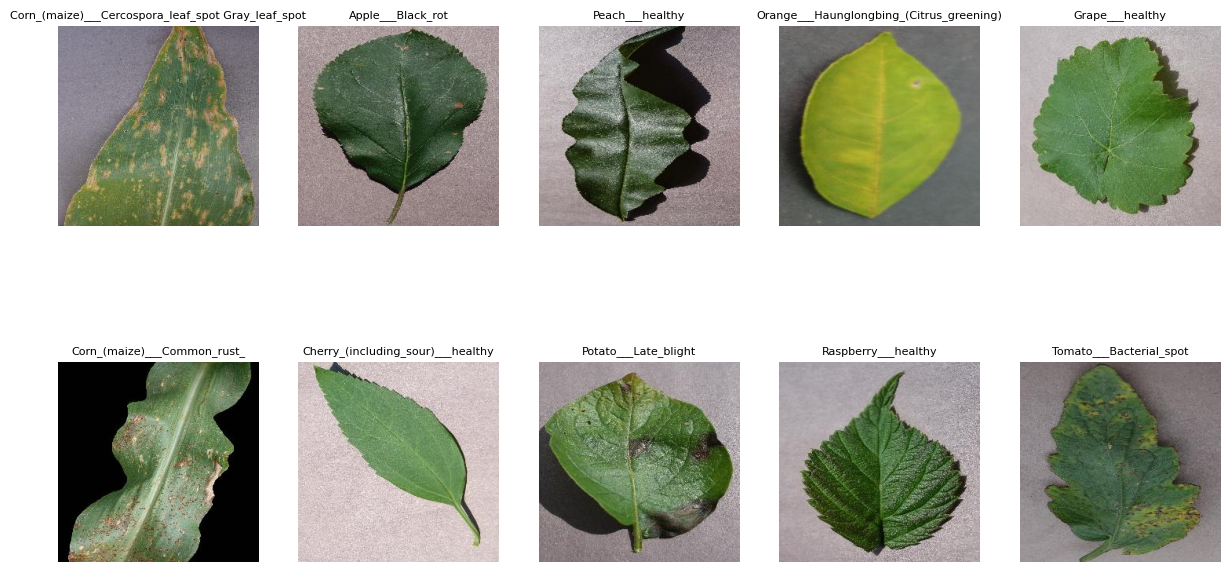

In [6]:
fig , axes = plt.subplots(2,5 , figsize=(15,8))
sample_classes = random.sample(class_names,10)
for ax , cls in zip(axes.flatten(),sample_classes):
    img_path = random.choice(
        glob.glob(
            os.path.join(DATA_DIR , cls , "*")
        )
    )
    img = keras.utils.load_img(img_path)
    ax.imshow(img)
    ax.set_title(cls , fontsize=8)
    ax.axis("off")


In [7]:
IMG_SIZE = (224 , 224)
BATCH_SIZE = 32 
all_paths = []
all_labels = []
print(type(all_paths))
for idx , clas in enumerate(class_names):
    files = glob.glob(
        os.path.join(DATA_DIR , clas , '*')
    )

    all_paths.extend(files)
    all_labels.extend([idx] * len(files)) # [2] * 3 = [2 , 2 , 2]
all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(all_paths , all_labels)
print(class_names)


<class 'list'>
['PlantVillage-Dataset\\raw\\color\\Apple___Apple_scab\\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'
 'PlantVillage-Dataset\\raw\\color\\Apple___Apple_scab\\01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'
 'PlantVillage-Dataset\\raw\\color\\Apple___Apple_scab\\01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG'
 ...
 'PlantVillage-Dataset\\raw\\color\\Tomato___healthy\\ff8b36d5-feaf-4d2d-8126-18670a312657___RS_HL 0229.JPG'
 'PlantVillage-Dataset\\raw\\color\\Tomato___healthy\\ffb39943-eabb-42cf-ad09-b17019e46d66___RS_HL 9871.JPG'
 'PlantVillage-Dataset\\raw\\color\\Tomato___healthy\\ffd8aa68-138f-4114-96c7-21eef72e1e13___RS_HL 9881.JPG'] [ 0  0  0 ... 37 37 37]
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Co

In [8]:
train_paths , temp_paths , train_labels , temp_labels = train_test_split(
    all_paths , 
    all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=SEED
)

In [9]:
val_paths , test_paths , val_labels , test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)
print(f"Train:{len(train_paths)} Val:{len(val_paths)} Test:{len(test_paths)}")


Train:38013 Val:8146 Test:8146

In [10]:
def load_and_preprocess(path , label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img , channels=3)
    img = tf.image.resize(img , IMG_SIZE)
    return img , label 

def make_datasets(path , labels , shuffle=False , augment=False):
    ds = tf.data.Dataset.from_tensor_slices((path , labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(path) , seed =SEED)
    ds = ds.map(load_and_preprocess , num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x , y :(data_augmentation(x , training=True) , y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds 

data_augmentation = keras.Sequential([
    layers.RandomFlip("Horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
],name="data_augmentation")

train_ds = make_datasets(train_paths , train_labels , shuffle=True , augment=True)
val_ds = make_datasets(val_paths , val_labels)
test_ds = make_datasets(test_paths , test_labels)


In [11]:
# Class Weights (handling imbalance)
class_weights_arr = compute_class_weight(
    class_weight="balanced" , classes=np.arange(len(class_names)) , y=train_labels
)
class_weight = {i : w for i , w in enumerate(class_weights_arr)}
print("Sample class weights:",dict(list(class_weight.items())[:5]))

Sample class weights: {0: np.float64(2.2683494450411743), 1: np.float64(2.2996370235934664), 2: np.float64(5.183119716389419), 3: np.float64(0.8683525219298246), 4: np.float64(0.9518002904501978)}


# 5 Build the Model - EfficientNetB0 Transfer Learning

In [ ]:
Num_classes = len(class_names)

base_model = keras.application.EfficientNet0(
     include_top = False , weights ="imagenet" , input_shape=IMG_SIZE + (3,)
 )

base_model.trainable = False 

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = keras.application.efficientnet.preprocess_input(inputs)
x = base_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(Num_classes , activation="softmax")(x)
model = keras.model(inputs , output , name="plant_disease_effnet0")
model.summary()


In [13]:
Num_classes = len(class_names)

base_model = keras.applications.EfficientNetB0(
    include_top = False , weights="imagenet" , input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(Num_classes , activation="softmax")(x)

model = keras.Model(inputs , outputs , name="plant_disease_effnetb0") 
model.summary()


Model: "plant_disease_effnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
       optimizer=keras.optimizers.Adam(learning_rate=1e-3),
       loss="sparse_categorical_crossentropy",
       metrics=["accuracy"]
   )

callbacks = [
       keras.callbacks.EarlyStopping(patience=3 , restore_best_weights=True , monitor="val_accuracy"),
       keras.callbacks.ReduceLROnPlateau(factor=0.5 , patience=2 , monitor="val_loss"),
       keras.callbacks.ModelCheckpoint("best_head_model.keras",save_best_only=True , monitor="val_accuracy"),

   ]

EPOCHS_HEAD = 10 

history_head = model.fit(
       train_ds,
       validation_data=val_ds,
       epochs=EPOCHS_HEAD,
       class_weight=class_weight,
       callbacks=callbacks
  )

In [ ]:
# # Stage B : Fine-Tune the top of the backbone
  # Unfreeze the last ~30 layers of EfficientNetB0 and continue training at a low learning rate (1e-5).

base_model.trainable = True 
for layer in base_model.layers[:-30]:
    layer.trainable = False 

model.compile(
      optimizer = keras.optimizers.Adam(learning_rate=1e-5),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

EPOCHS_FINE = 10

callbacks_fine = [
      keras.callbacks.EarlyStopping(patience=3 , restore_best_weights=True , monitor="val_accuracy"),
      keras.callbacks.ModelCheckpoint("best_finetuned_model.keras" , save_best_only=True , monitor="val_accuracy")
  ]

history_fine = model.fit(
      train_ds,
      validation_data = val_ds,
      epochs=EPOCHS_FINE,
      class_weight=class_weight,
      callbacks=callbacks_fine
  )


Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2889s 2s/step - accuracy: 0.2608 - loss: 3.0521 - val_accuracy: 0.6183 - val_loss: 2.2704
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2055s 2s/step - accuracy: 0.6739 - loss: 1.8180 - val_accuracy: 0.8030 - val_loss: 1.2735
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2792s 2s/step - accuracy: 0.8087 - loss: 1.0783 - val_accuracy: 0.8677 - val_loss: 0.7352
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2030s 2s/step - accuracy: 0.8627 - loss: 0.7223 - val_accuracy: 0.8922 - val_loss: 0.5028
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2023s 2s/step - accuracy: 0.8852 - loss: 0.5354 - val_accuracy: 0.9120 - val_loss: 0.3787
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2191s 2s/step - accuracy: 0.9029 - loss: 0.4233 - val_accuracy: 0.9246 - val_loss: 0.3054
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2306s 2s/step - accuracy: 0.9163 - loss: 0.3501 - val_accuracy: 0.9337 - val_loss: 0.2547
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1903s 2s/step - accuracy: 0.9227 -

In [16]:
def plot_history(h1 , h2=None):
   acc = h1.history["accuracy"] + (h2.history["accuracy"] if h2 else [])
   val_acc = h1.history["val_accuracy"] + (h2.history["val_accuracy"] if h2 else [])
   loss = h1.history["loss"] + (h2.history["loss"] if h2 else [])
   val_loss = h1.history["val_loss"] + (h2.history["val_loss"] if h2 else [])

   fig, axes = plt.subplots(1, 2, figsize=(12, 4))
   axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
   axes[0].set_title("Accuracy"); axes[0].legend()
   axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="val")
   axes[1].set_title("Loss"); axes[1].legend()
   plt.tight_layout(); plt.show()


In [18]:
# Evaluate on the Test set 
test_loss , test_acc = model.evaluate(test_ds)
print(f"Test accuracy:{test_acc:.4f}")

y_true = test_labels
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs , axis=1)

print(classification_report(y_true,y_pred , target_names=class_names,zero_division=0))


255/255 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9479 - loss: 0.1779
Test accuracy:0.9479
255/255 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      1.00      0.98        94
                                 Apple___Black_rot       0.98      0.99      0.98        93
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        41
                                   Apple___healthy       1.00      0.95      0.97       246
                               Blueberry___healthy       0.97      1.00      0.99       226
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.99       158
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.86      0.85        77
                       Corn_(mai

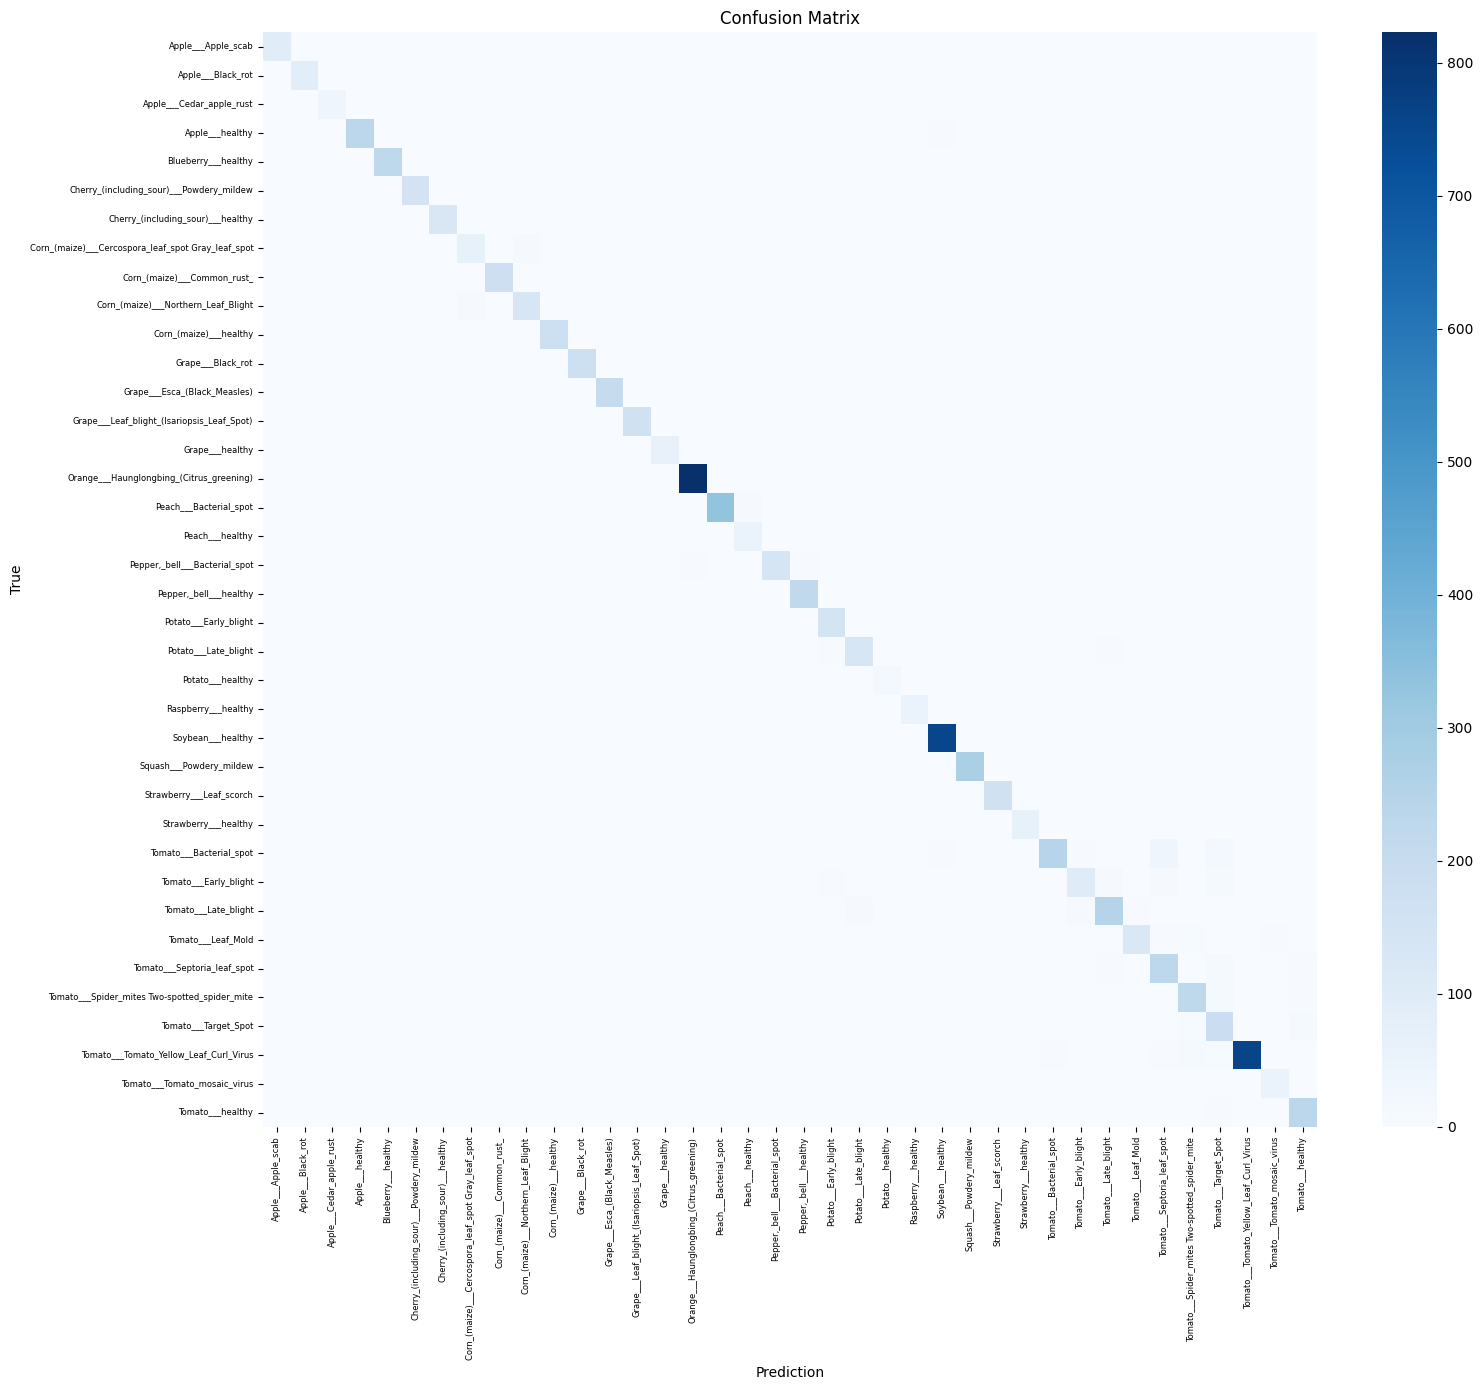

In [19]:
cm = confusion_matrix(y_true , y_pred)
plt.figure(figsize=(16,14))
sns.heatmap(cm , cmap="Blues" , xticklabels=class_names , yticklabels=class_names)
plt.xticks(rotation=90 , fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("Prediction");plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Grad-CAM Explainability

# step 1 . find the last convolutional layer 


last_conv_layer_name = None 

for layer in reversed(base_model.layers):
    if isinstance(layer , layers.Conv2D):
        last_conv_layer_name = layer.name
        break
# Why last conv layer -> GradCam works on the last convolutional layer because 
#Earliest layers -> Edges , Textures , Corners 
#Middle Layers -> Eyes , Leaves , Wheel 
#Last Conv Layer -> Dog , cat , Tumor , Pnemonia
# It contains the highest level spatial information 

#Step 2 : Create a New Model 
grad_model = keras.Model(
    inputs = base_model.input , 
    outputs = [
        base_model.get_layer(last_conv_layer_name).output,
        base_model.output
    ]
)

def make_gradcam_headmap(img_array , pred_index=None):
    # Record Gradient
    with tf.GradientTape() as tape:
        conv_output , preds_backbone = grad_model(img_array)
        pooled = layers.GlobalAveragePooling2D()(preds_backbone)
        head_preds = model.get_layer(index=-1)(model.get_layer(index=-2)(pooled))
        if pred_index is None:
            pred_index = tf.argmax(head_preds[0])
        class_channel = head_preds[: , pred_index]
    #Compute Gradient
    grads = tape.gradient(class_channel , conv_output)
    pooled_grads = tf.reduce_mean(grads , axis=(0,1,2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap , 0) 
    #GradCam only keeps positive contributions

    #Normalize 
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy() , int(pred_index)


C:\Users\shashank pandit\AppData\Local\Temp\ipykernel_8300\3194357557.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm_module.get_cmap("jet")


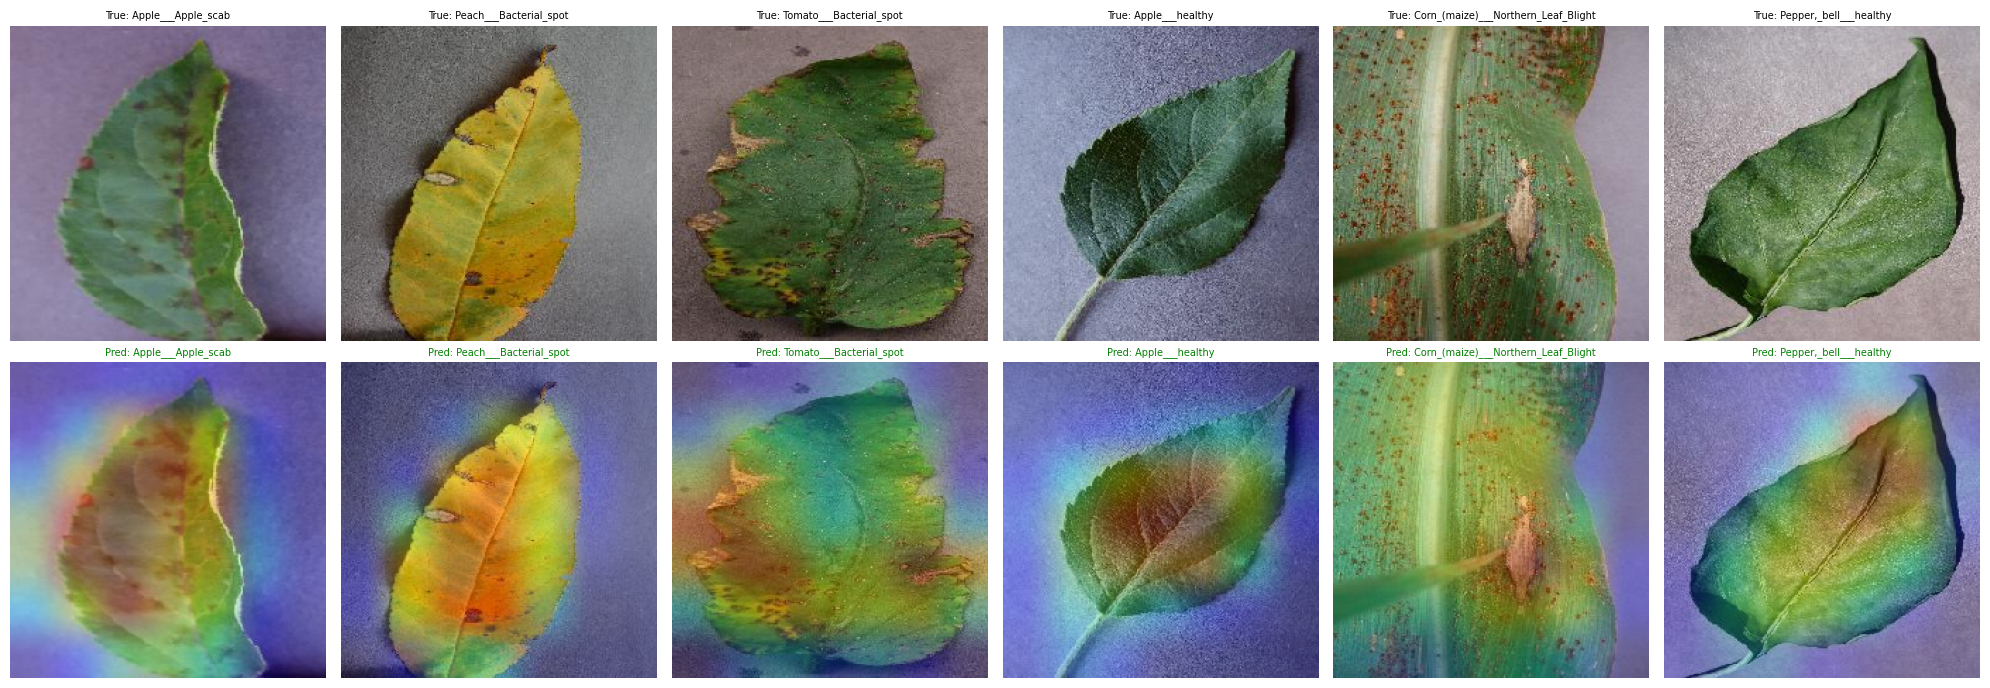

In [24]:
import matplotlib.cm as cm_module

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img = keras.utils.img_to_array(img)

    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm_module.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img
    superimposed = keras.utils.array_to_img(superimposed)
    return img.astype("uint8"), superimposed

# Run Grad-CAM on a handful of random test images
sample_idxs = random.sample(range(len(test_paths)), 6)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, idx in enumerate(sample_idxs):
    path = test_paths[idx]
    true_label = class_names[test_labels[idx]]

    img = keras.utils.load_img(path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_array = keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, pred_idx = make_gradcam_headmap(img_array)
    pred_label = class_names[pred_idx]

    orig, overlay = display_gradcam(path, heatmap)

    axes[0, i].imshow(orig); axes[0, i].axis("off")
    axes[0, i].set_title(f"True: {true_label}", fontsize=7)
    axes[1, i].imshow(overlay); axes[1, i].axis("off")
    axes[1, i].set_title(f"Pred: {pred_label}", fontsize=7,
                          color="green" if pred_label == true_label else "red")

plt.tight_layout()
plt.show()

In [25]:
model.save("plant_disease_classifier_final.keras")
print("Saved model to plant_disease_classifier_final.keras")

Saved model to plant_disease_classifier_final.keras


In [1]:
import tensorflow as tf

# 1. Load the model
model = tf.keras.models.load_model('plant_disease_classifier_final.keras')

# 2. Evaluate on your test dataset
# (Assumes you have test_images and test_labels prepared)
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


NameError: name 'test_ds' is not defined